In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

## Read the data

In [3]:
!ls *.csv

data.csv
healthy-life-expectancy-at-birth.csv
life-expectancy-of-women-vs-life-expectancy-of-men.csv
owid_literacy.csv
wef_earned_income.csv
wef_earned_income_table.csv
wef_economic_participation.csv
wef_educational_attainment.csv
wef_head_of_state.csv
wef_head_of_state_table.csv
wef_health_and_survival.csv
wef_labour_participation.csv
wef_labour_participation_table.csv
wef_legislators.csv
wef_legislators_table.csv
wef_life_expectancy.csv
wef_life_expectancy_table.csv
wef_literacy_rate.csv
wef_literacy_rate_table.csv
wef_ministerial_positions.csv
wef_ministerial_table.csv
wef_parliament_table.csv
wef_political_empowerment.csv
wef_primary_enrolment.csv
wef_primary_enrolment_table.csv
wef_professional_and_technical_workers.csv
wef_professionals_table.csv
wef_secondary_enrolment.csv
wef_secondary_enrolment_table.csv
wef_sex_ratio.csv
wef_sex_ratio_table.csv
wef_tertiary_enrolment.csv
wef_tertiary_enrolment_table.csv
wef_wage_equality.csv
wef_wage_equality_table.csv
wef_women_in_parliament

In [4]:
xlabel = 'Women in Parliament'

In [5]:

import os
from extract_pdf_data import read_pdfs

filename = "wef_women_in_parliament.csv"
if not os.path.exists(filename):
    df = read_pdfs('legislators')
    df.to_csv(filename, index=False)

In [6]:
from utils import read_wef_file

df = read_wef_file(filename)
df.head()

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ALB,Albania,83,0.555,40.0,-28.6,35.7,64.3
DZA,Algeria,85,0.086,132.0,-84.2,7.9,92.1
AGO,Angola,87,0.629,28.0,-22.8,38.6,61.4
ARG,Argentina,89,0.736,21.0,-15.2,42.4,57.6
ARM,Armenia,91,0.575,38.0,-27.0,36.5,63.5


In [7]:
df['rank'].value_counts(dropna=False).head()

rank
NaN      4
94.0     4
1.0      4
29.0     3
118.0    2
Name: count, dtype: int64

In [8]:
df['score'].describe()

count    142.000000
mean       0.412366
std        0.250310
min        0.000000
25%        0.228500
50%        0.375000
75%        0.596500
max        1.000000
Name: score, dtype: float64

In [9]:
dinged = df['score'] < 1
dinged.sum()

138

Here is the distribution of their scores.

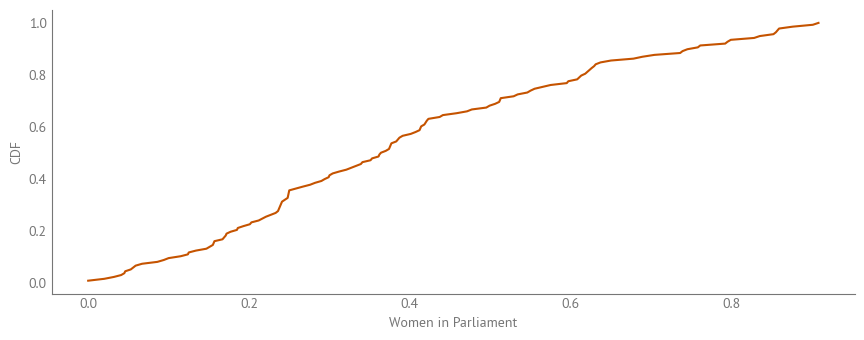

In [10]:
from empiricaldist import Cdf

cdf_score = Cdf.from_seq(df.loc[dinged, 'score'])
cdf_score.plot()
decorate(xlabel=xlabel, ylabel='CDF')

In [11]:
subset = df[dinged]
subset.sort_values("diff", ascending=False)

,country,page_number,score,rank,diff,left,right
code,,,,,,,
ISL,Iceland,203,0.908,5.0,-4.8,47.6,52.4
CRI,Costa Rica,151,0.901,6.0,-5.2,47.4,52.6
SWE,Sweden,335,0.876,7.0,-6.6,46.7,53.3
ZAF,South Africa,323,0.859,8.0,-7.6,46.2,53.8
BOL,Bolivia,115,0.859,8.0,-7.6,46.2,53.8
...,...,...,...,...,...,...,...
BTN,Bhutan,113,0.045,138.0,-91.4,4.3,95.7
NGA,Nigeria,281,0.041,139.0,-92.2,3.9,96.1
KWT,Kuwait,227,0.032,140.0,-93.8,3.1,96.9


## Revised scores

The scores are based on ratios, not differences, so let's compute those.

In [12]:
df['ratio'] = df['left'] / df['right']
df['ratio'].describe()

count    142.000000
mean       0.408605
std        0.243604
min        0.000000
25%        0.228507
50%        0.374571
75%        0.596807
max        1.000000
Name: ratio, dtype: float64

Looks like the ratio IS the score.

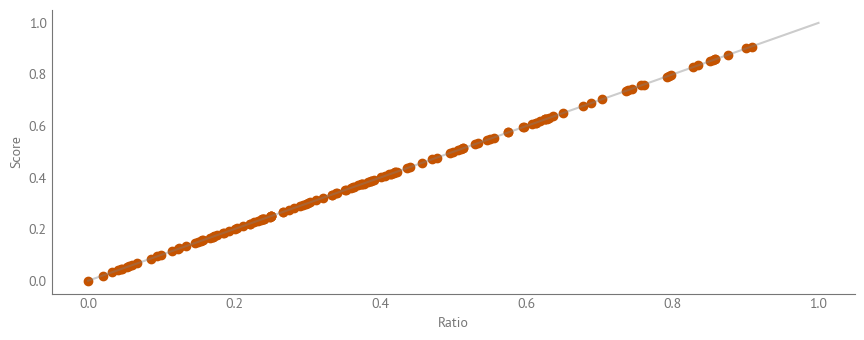

In [13]:
subset = df[dinged]
plt.plot([0, 1], [0, 1], color='gray', alpha=0.4)
plt.scatter(subset['ratio'], subset['score'])
decorate(xlabel='Ratio', ylabel='Score')

So here are the revised, symmetric scores.

In [14]:
df['revised_score'] = df['ratio']
df['revised_score'].describe()

count    142.000000
mean       0.408605
std        0.243604
min        0.000000
25%        0.228507
50%        0.374571
75%        0.596807
max        1.000000
Name: revised_score, dtype: float64

Here's the distribution of revised scores.

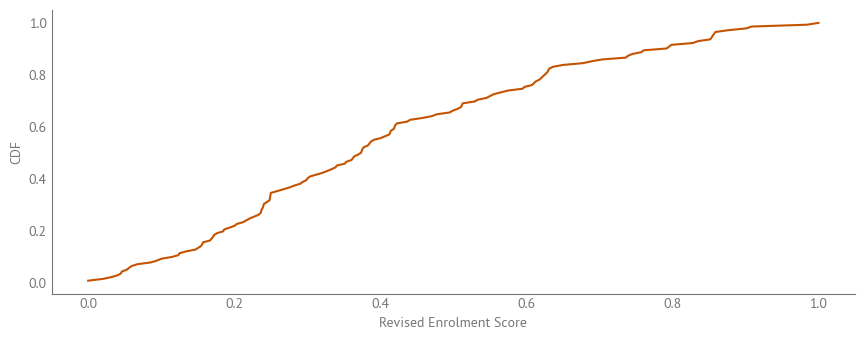

In [15]:
cdf_score = Cdf.from_seq(df['revised_score'])
cdf_score.plot()
decorate(xlabel='Revised Enrolment Score', ylabel='CDF')

Here's the distribution of revised scores, compare to the original.

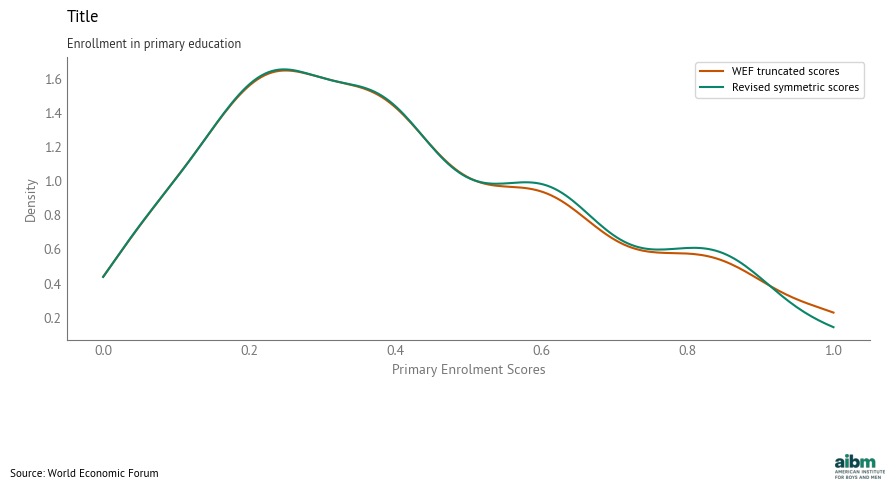

In [16]:
from utils import plot_score_distributions, add_title

plot_score_distributions(df, xlabel='Primary Enrolment Scores')
add_title("Title",
          "Enrollment in primary education")

In [17]:
revised = df[~dinged].dropna(subset=['ratio']).sort_values('revised_score')
revised.shape

(4, 9)

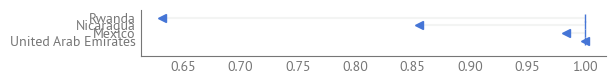

In [18]:
from utils import plot_revised_scores

plot_revised_scores(revised)

## Export the results

In [19]:
from utils import make_rank_table

table = make_rank_table(df)
table.to_csv("wef_parliament_table.csv")
table.shape

(146, 6)

In [20]:
table['score'].describe()

count    142.000000
mean       0.412366
std        0.250310
min        0.000000
25%        0.228500
50%        0.375000
75%        0.596500
max        1.000000
Name: score, dtype: float64

In [21]:
from utils import make_weight_table

make_weight_table(table, 'parliament')

original             revised         
                std   inv std       std  inv std
parliament  0.25031  0.039951  0.243604  0.04105

## OECD countries

In [22]:
from utils import oecd_codes

df_oecd = df.loc[oecd_codes].sort_values(by='revised_score')

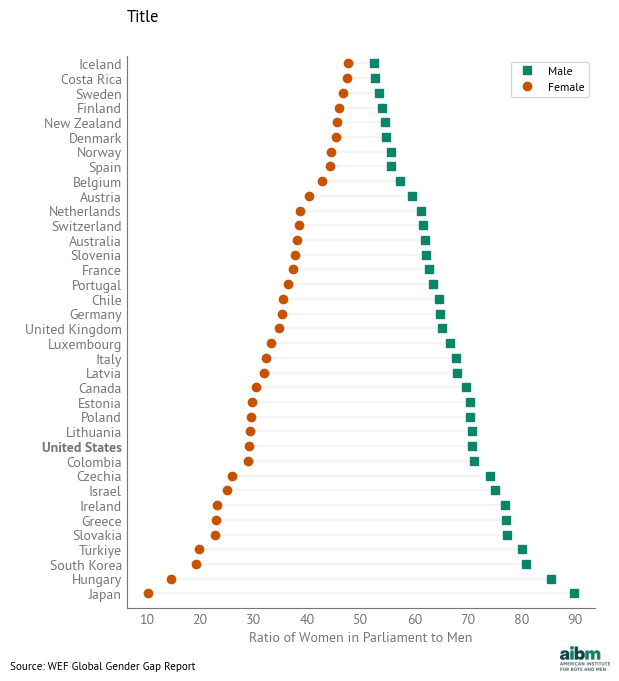

In [23]:
from utils import plot_percentages

plot_percentages(df_oecd)
plt.xlabel('Ratio of Women in Parliament to Men')
add_title("Title",
          " ", y=1.01)


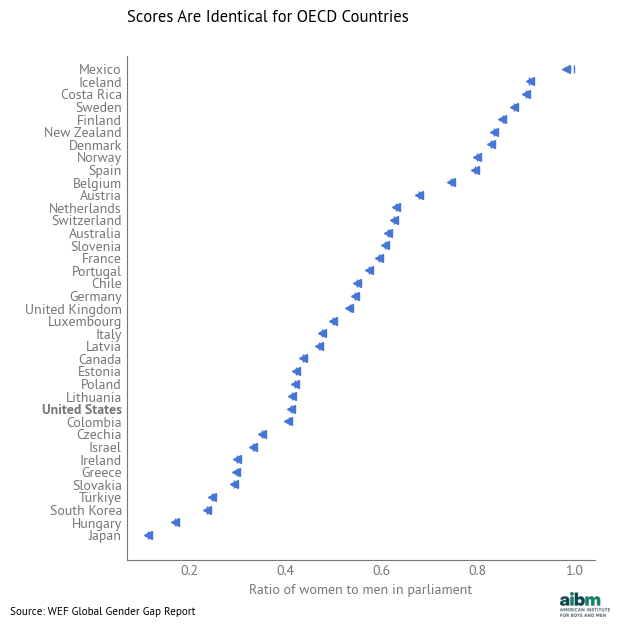

In [24]:
from utils import plot_revised_scores
from utils import add_title, add_subtext, add_logo

plot_revised_scores(df_oecd.sort_values(by='score', ascending=False))
decorate(xlabel='Ratio of women to men in parliament')
add_title('Scores Are Identical for OECD Countries',
          '', y=1.02)
add_subtext('Source: WEF Global Gender Gap Report', y=-0.01)
logo = add_logo(location=(1.0, -0.01))

In [25]:
df.query("country == 'Ireland'")

,country,page_number,score,rank,diff,left,right,ratio,revised_score,revised_rank
code,,,,,,,,,,
IRL,Ireland,211,0.3,86.0,-53.8,23.1,76.9,0.30039,0.30039,86.0
